In [1]:
import numpy as np

# Original matrix (users × movies)
A = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [1, 0, 0, 4],
    [0, 1, 5, 4],
])

# Perform Singular Value Decomposition
U, S, VT = np.linalg.svd(A, full_matrices=False)

# Keep only top 2 latent factors
k = 2
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]

# Approximate reconstruction
A_approx = U_k @ S_k @ VT_k

print("Original A:\n", A)
print("\nReconstructed (approx):\n", np.round(A_approx, 2))


Original A:
 [[5 3 0 1]
 [4 0 0 1]
 [1 1 0 5]
 [1 0 0 4]
 [0 1 5 4]]

Reconstructed (approx):
 [[ 5.13  1.91 -0.72  1.56]
 [ 3.43  1.28 -0.46  1.09]
 [ 1.55  1.04  1.79  3.97]
 [ 1.18  0.8   1.4   3.09]
 [-0.45  0.54  3.1   5.15]]


Image shape: (710, 710)
Block missing region: top=559, left=629, h=30, w=30
Iter 0, loss = 188301.4613


C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:84: RuntimeWarning: overflow encountered in square
  loss = np.sum(E**2)
C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:81: RuntimeWarning: overflow encountered in matmul
  X_hat = U @ V.T
C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:81: RuntimeWarning: invalid value encountered in matmul
  X_hat = U @ V.T
C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:82: RuntimeWarning: invalid value encountered in multiply
  E = (X_hat - X) * M   # only observed entries contribute


Iter 500, loss = nan
Iter 1000, loss = nan
Iter 1500, loss = nan
Iter 2000, loss = nan
Iter 2500, loss = nan
Iter 3000, loss = nan
Iter 3500, loss = nan
Iter 4000, loss = nan
Iter 4500, loss = nan

[Block Missing] Rank=20
RMSE (on missing region) = nan
PSNR (on missing region) = nan dB


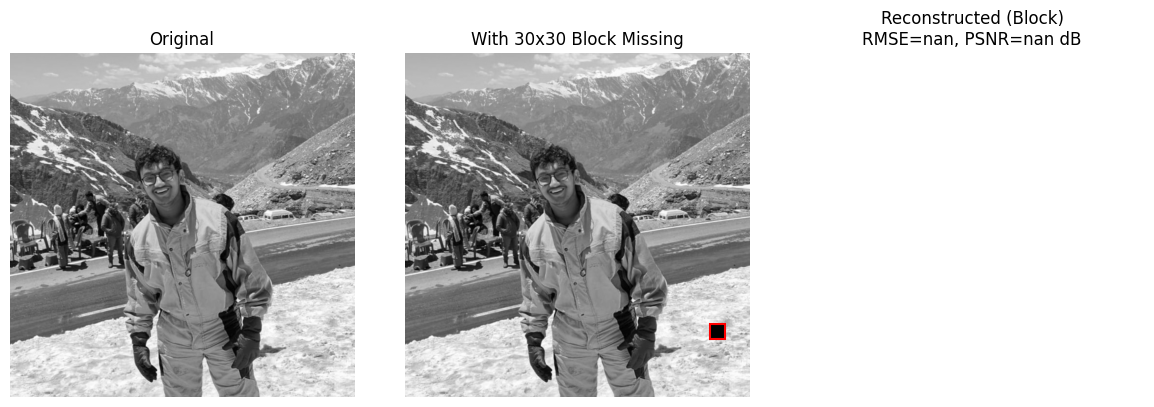

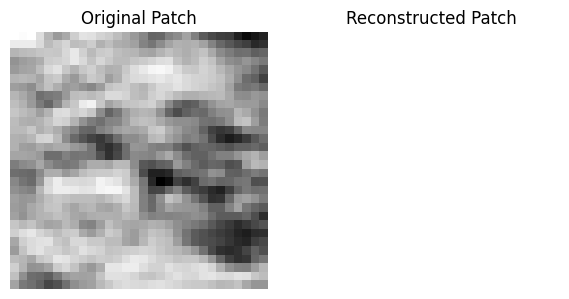

Iter 0, loss = 188463.0114


C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:91: RuntimeWarning: overflow encountered in matmul
  dU = 2 * E @ V
C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\593021567.py:92: RuntimeWarning: overflow encountered in matmul
  dV = 2 * E.T @ U


Iter 500, loss = nan
Iter 1000, loss = nan
Iter 1500, loss = nan
Iter 2000, loss = nan
Iter 2500, loss = nan
Iter 3000, loss = nan
Iter 3500, loss = nan
Iter 4000, loss = nan
Iter 4500, loss = nan

[Random Missing] Rank=20
RMSE (on missing pixels) = nan
PSNR (on missing pixels) = nan dB


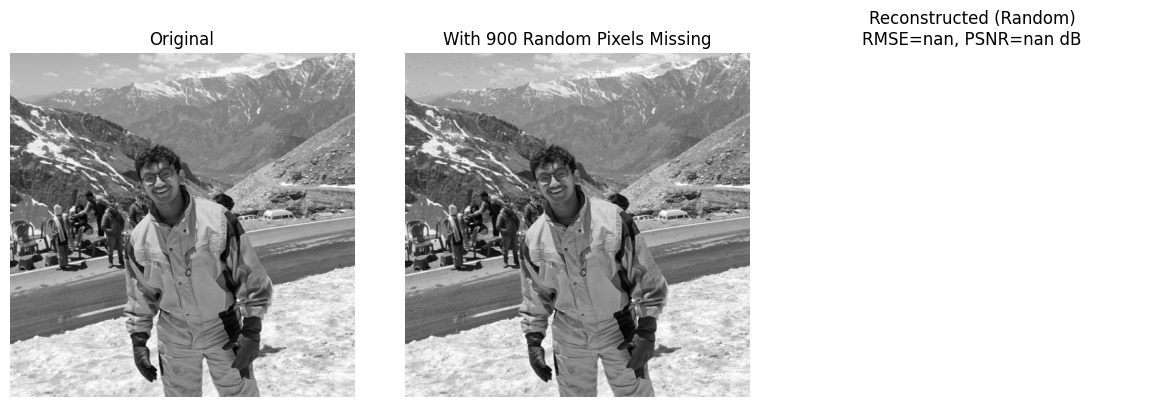

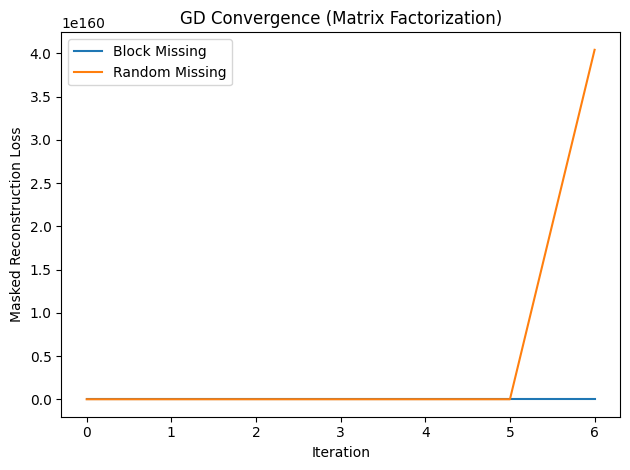

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# 1. Load and preprocess image
# =========================

# TODO: change this to your image path
IMAGE_PATH = "Profile_pic.jpg"   # can be .jpg, .png, etc.

# Read image
img = imread(IMAGE_PATH)

# Convert to grayscale if it's RGB
if img.ndim == 3:
    # simple average over channels
    img_gray = img.mean(axis=2)
else:
    img_gray = img

# Normalize to [0, 1]
img_gray = img_gray.astype(float)
img_min, img_max = img_gray.min(), img_gray.max()
if img_max > img_min:
    img_gray = (img_gray - img_min) / (img_max - img_min)

X_full = img_gray  # ground truth
m, n = X_full.shape
print("Image shape:", X_full.shape)


# =========================
# 2. Mask creation
# =========================

def make_block_mask(shape, block_h=30, block_w=30, top=None, left=None):
    m, n = shape
    M = np.ones((m, n), dtype=float)

    # choose top-left of block if not provided
    if top is None:
        top = np.random.randint(0, m - block_h + 1)
    if left is None:
        left = np.random.randint(0, n - block_w + 1)

    M[top:top+block_h, left:left+block_w] = 0.0
    return M, (top, left, block_h, block_w)

def make_random_mask(shape, num_missing=900):
    m, n = shape
    M = np.ones((m, n), dtype=float)
    total_pixels = m * n
    num_missing = min(num_missing, total_pixels)
    # choose random flat indices
    idx = np.random.choice(total_pixels, size=num_missing, replace=False)
    M.flat[idx] = 0.0
    return M


# =========================
# 3. Low-rank matrix factorization with GD
# =========================

def matrix_factorization_gd(X, M, rank=20, lr=1e-2, max_iters=5000, tol=1e-5, verbose=True):
    """
    X: full image matrix (m x n)
    M: mask matrix (m x n), 1 for observed, 0 for missing
    rank: low rank r
    lr: learning rate
    """
    m, n = X.shape
    r = rank
    # initialize U, V
    U = 0.1 * np.random.randn(m, r)
    V = 0.1 * np.random.randn(n, r)

    losses = []

    for t in range(max_iters):
        X_hat = U @ V.T
        E = (X_hat - X) * M   # only observed entries contribute

        loss = np.sum(E**2)
        losses.append(loss)

        if verbose and t % 500 == 0:
            print(f"Iter {t}, loss = {loss:.4f}")

        # gradients
        dU = 2 * E @ V
        dV = 2 * E.T @ U

        U -= lr * dU
        V -= lr * dV

        # simple convergence check on loss
        if t > 0 and abs(losses[-2] - losses[-1]) < tol:
            if verbose:
                print(f"Converged at iter {t}, loss={loss:.4f}")
            break

    X_rec = U @ V.T
    return X_rec, U, V, np.array(losses)


# =========================
# 4. Metrics: RMSE and PSNR
# =========================

def rmse(gt, pred, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]  # often we care about missing region
    else:
        diff = gt - pred
    return np.sqrt(np.mean(diff**2))

def psnr(gt, pred, max_val=1.0, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]
    else:
        diff = gt - pred
    mse_val = np.mean(diff**2)
    if mse_val == 0:
        return float("inf")
    return 20 * np.log10(max_val / np.sqrt(mse_val))


# =========================
# 5. Case (a): 30x30 block missing
# =========================

np.random.seed(0)

M_block, (top, left, bh, bw) = make_block_mask(X_full.shape, block_h=30, block_w=30)
X_block = X_full * M_block  # corrupted image (zeroed in missing region)

print("Block missing region: top={}, left={}, h={}, w={}".format(top, left, bh, bw))

# Perform matrix factorization
rank = 20   # choose rank r here
X_rec_block, U_block, V_block, losses_block = matrix_factorization_gd(
    X_full, M_block, rank=rank, lr=1e-2, max_iters=5000, tol=1e-5, verbose=True
)

rmse_block = rmse(X_full, X_rec_block, mask=M_block)
psnr_block = psnr(X_full, X_rec_block, max_val=1.0, mask=M_block)

print(f"\n[Block Missing] Rank={rank}")
print(f"RMSE (on missing region) = {rmse_block:.4f}")
print(f"PSNR (on missing region) = {psnr_block:.2f} dB")

# =========================
# Plot for block case
# =========================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_block, cmap='gray')
axes[1].set_title("With 30x30 Block Missing")
axes[1].add_patch(
    plt.Rectangle((left, top), bw, bh, edgecolor='red', facecolor='none', linewidth=1.5)
)
axes[1].axis('off')

axes[2].imshow(X_rec_block, cmap='gray')
axes[2].set_title(f"Reconstructed (Block)\nRMSE={rmse_block:.4f}, PSNR={psnr_block:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Optionally, zoomed-in patch visualization
patch_orig = X_full[top:top+bh, left:left+bw]
patch_rec = X_rec_block[top:top+bh, left:left+bw]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(patch_orig, cmap='gray')
axes[0].set_title("Original Patch")
axes[0].axis('off')

axes[1].imshow(patch_rec, cmap='gray')
axes[1].set_title("Reconstructed Patch")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# =========================
# 6. Case (b): 900 random pixels missing
# =========================

np.random.seed(1)

M_rand = make_random_mask(X_full.shape, num_missing=900)
X_rand = X_full * M_rand

X_rec_rand, U_rand, V_rand, losses_rand = matrix_factorization_gd(
    X_full, M_rand, rank=rank, lr=1e-2, max_iters=5000, tol=1e-5, verbose=True
)

rmse_rand = rmse(X_full, X_rec_rand, mask=M_rand)
psnr_rand = psnr(X_full, X_rec_rand, max_val=1.0, mask=M_rand)

print(f"\n[Random Missing] Rank={rank}")
print(f"RMSE (on missing pixels) = {rmse_rand:.4f}")
print(f"PSNR (on missing pixels) = {psnr_rand:.2f} dB")

# Plot for random case
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_rand, cmap='gray')
axes[1].set_title("With 900 Random Pixels Missing")
axes[1].axis('off')

axes[2].imshow(X_rec_rand, cmap='gray')
axes[2].set_title(f"Reconstructed (Random)\nRMSE={rmse_rand:.4f}, PSNR={psnr_rand:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Plot losses (optional)
plt.figure()
plt.plot(losses_block, label="Block Missing")
plt.plot(losses_rand, label="Random Missing")
plt.xlabel("Iteration")
plt.ylabel("Masked Reconstruction Loss")
plt.title("GD Convergence (Matrix Factorization)")
plt.legend()
plt.tight_layout()
plt.show()


Image shape: (710, 710)
Block missing region → top=559, left=629, h=30, w=30
Iter 0, loss = 0.372118
Converged at iter 1, loss=0.372118

[Block Missing] Rank=20
RMSE (on missing region) = 0.8629
PSNR (on missing region) = 1.28 dB


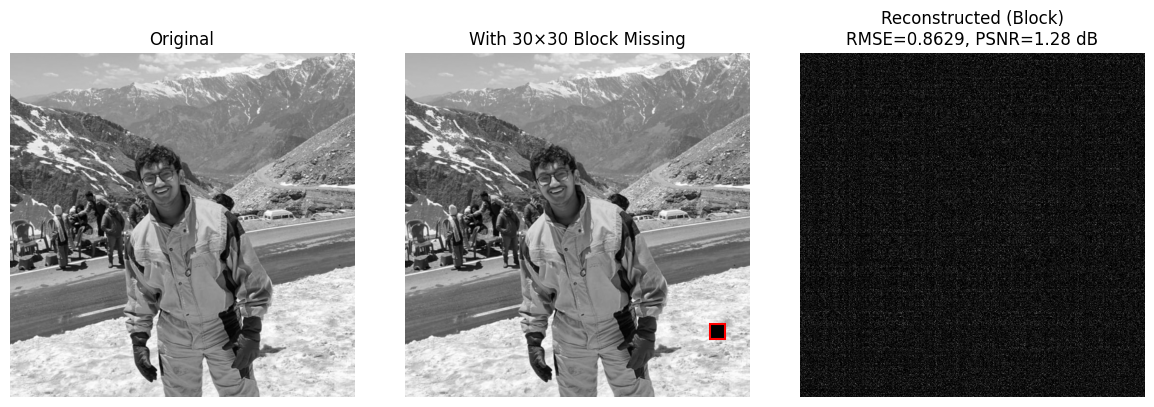

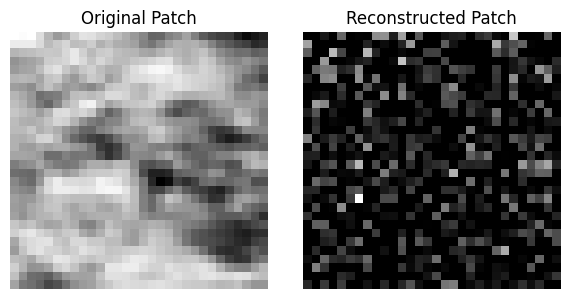

Iter 0, loss = 0.372759
Converged at iter 1, loss=0.372759

[Random Missing] Rank=20
RMSE (on missing pixels) = 0.6207
PSNR (on missing pixels) = 4.14 dB


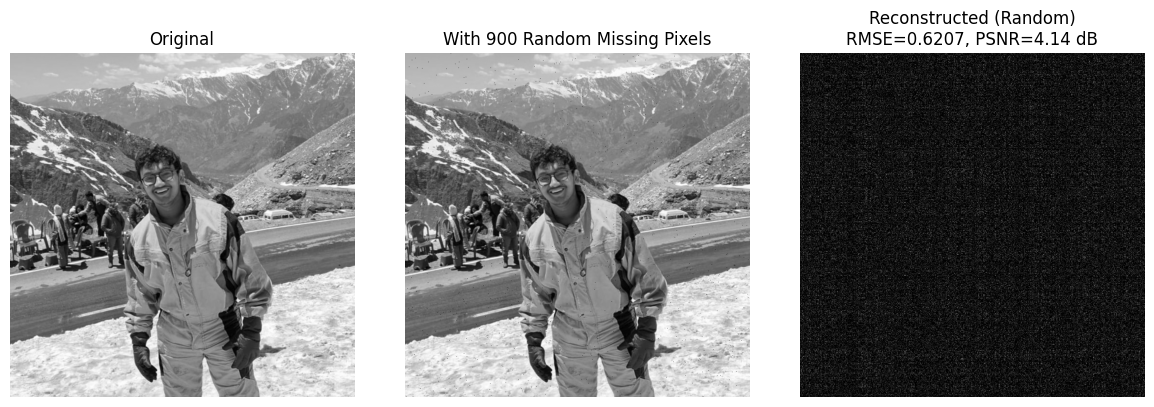

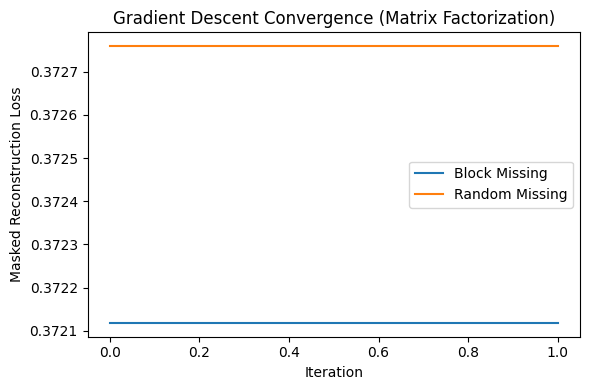

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# 0. Config
# =========================

# 🔴 CHANGE THIS to your image path
IMAGE_PATH = "Profile_pic.jpg"   # e.g. "lena.png", "cameraman.png"

RANK = 20        # low-rank r you want to use
BLOCK_SIZE = 30  # 30x30 block
NUM_MISSING = 900  # for random missing pixels


# =========================
# 1. Load & preprocess image
# =========================

img = imread(IMAGE_PATH)

# Convert to grayscale if RGB
if img.ndim == 3:
    img_gray = img.mean(axis=2)
else:
    img_gray = img

# Normalize to [0,1]
img_gray = img_gray.astype(float)
img_min, img_max = img_gray.min(), img_gray.max()
if img_max > img_min:
    img_gray = (img_gray - img_min) / (img_max - img_min)

X_full = img_gray  # ground truth image matrix
m, n = X_full.shape
print("Image shape:", X_full.shape)


# =========================
# 2. Mask creation helpers
# =========================

def make_block_mask(shape, block_h=30, block_w=30, top=None, left=None):
    m, n = shape
    M = np.ones((m, n), dtype=float)

    # random location if not provided
    if top is None:
        top = np.random.randint(0, m - block_h + 1)
    if left is None:
        left = np.random.randint(0, n - block_w + 1)

    M[top:top + block_h, left:left + block_w] = 0.0
    return M, (top, left, block_h, block_w)

def make_random_mask(shape, num_missing=900):
    m, n = shape
    M = np.ones((m, n), dtype=float)
    total_pixels = m * n
    num_missing = min(num_missing, total_pixels)
    idx = np.random.choice(total_pixels, size=num_missing, replace=False)
    M.flat[idx] = 0.0
    return M


# =========================
# 3. Matrix factorization via Gradient Descent
# =========================

def matrix_factorization_gd(X, M, rank=20, lr=1e-4, max_iters=5000, tol=1e-6, verbose=True):
    """
    X: ground truth image (m x n), values in [0,1]
    M: mask (m x n), 1 = observed, 0 = missing
    rank: low-rank dimension r
    lr: learning rate
    """
    m, n = X.shape
    r = rank

    # Initialize U, V small
    U = 0.01 * np.random.randn(m, r)
    V = 0.01 * np.random.randn(n, r)

    losses = []
    obs_count = M.sum()  # number of observed pixels

    for t in range(max_iters):
        X_hat = U @ V.T
        E = (X_hat - X) * M  # error only on observed entries

        # Mean squared error over observed entries
        loss = np.sum(E**2) / obs_count
        losses.append(loss)

        if verbose and t % 500 == 0:
            print(f"Iter {t}, loss = {loss:.6f}")

        if not np.isfinite(loss):
            print("Loss became NaN/Inf, stopping.")
            break

        # Gradients averaged over observed entries
        dU = (2.0 / obs_count) * (E @ V)
        dV = (2.0 / obs_count) * (E.T @ U)

        # Gradient descent update
        U -= lr * dU
        V -= lr * dV

        # Convergence check
        if t > 0 and abs(losses[-2] - losses[-1]) < tol:
            if verbose:
                print(f"Converged at iter {t}, loss={loss:.6f}")
            break

    X_rec = U @ V.T
    X_rec = np.clip(X_rec, 0.0, 1.0)  # keep valid pixel range
    return X_rec, U, V, np.array(losses)


# =========================
# 4. Metrics: RMSE & PSNR
# =========================

def rmse(gt, pred, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]  # only missing region
    else:
        diff = gt - pred
    return np.sqrt(np.mean(diff**2))

def psnr(gt, pred, max_val=1.0, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]
    else:
        diff = gt - pred
    mse_val = np.mean(diff**2)
    if mse_val == 0:
        return float("inf")
    return 20 * np.log10(max_val / np.sqrt(mse_val))


# =========================
# 5. Case (a): 30x30 block missing
# =========================

np.random.seed(0)
M_block, (top, left, bh, bw) = make_block_mask(X_full.shape, block_h=BLOCK_SIZE, block_w=BLOCK_SIZE)
X_block = X_full * M_block

print("Block missing region → top={}, left={}, h={}, w={}".format(top, left, bh, bw))

X_rec_block, U_block, V_block, losses_block = matrix_factorization_gd(
    X_full, M_block, rank=RANK, lr=1e-4, max_iters=5000, tol=1e-7, verbose=True
)

rmse_block = rmse(X_full, X_rec_block, mask=M_block)
psnr_block = psnr(X_full, X_rec_block, max_val=1.0, mask=M_block)

print(f"\n[Block Missing] Rank={RANK}")
print(f"RMSE (on missing region) = {rmse_block:.4f}")
print(f"PSNR (on missing region) = {psnr_block:.2f} dB")

# Plot for block case
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_block, cmap='gray')
axes[1].set_title("With 30×30 Block Missing")
axes[1].add_patch(
    plt.Rectangle((left, top), bw, bh, edgecolor='red', facecolor='none', linewidth=1.5)
)
axes[1].axis('off')

axes[2].imshow(X_rec_block, cmap='gray')
axes[2].set_title(f"Reconstructed (Block)\nRMSE={rmse_block:.4f}, PSNR={psnr_block:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Optional: zoomed-in patch view
patch_orig = X_full[top:top+bh, left:left+bw]
patch_rec = X_rec_block[top:top+bh, left:left+bw]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(patch_orig, cmap='gray')
axes[0].set_title("Original Patch")
axes[0].axis('off')

axes[1].imshow(patch_rec, cmap='gray')
axes[1].set_title("Reconstructed Patch")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# =========================
# 6. Case (b): 900 random pixels missing
# =========================

np.random.seed(1)
M_rand = make_random_mask(X_full.shape, num_missing=NUM_MISSING)
X_rand = X_full * M_rand

X_rec_rand, U_rand, V_rand, losses_rand = matrix_factorization_gd(
    X_full, M_rand, rank=RANK, lr=1e-4, max_iters=5000, tol=1e-7, verbose=True
)

rmse_rand = rmse(X_full, X_rec_rand, mask=M_rand)
psnr_rand = psnr(X_full, X_rec_rand, max_val=1.0, mask=M_rand)

print(f"\n[Random Missing] Rank={RANK}")
print(f"RMSE (on missing pixels) = {rmse_rand:.4f}")
print(f"PSNR (on missing pixels) = {psnr_rand:.2f} dB")

# Plot for random case
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_rand, cmap='gray')
axes[1].set_title("With 900 Random Missing Pixels")
axes[1].axis('off')

axes[2].imshow(X_rec_rand, cmap='gray')
axes[2].set_title(f"Reconstructed (Random)\nRMSE={rmse_rand:.4f}, PSNR={psnr_rand:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 7. Plot GD loss curves (optional)
# =========================

plt.figure(figsize=(6,4))
plt.plot(losses_block, label="Block Missing")
plt.plot(losses_rand, label="Random Missing")
plt.xlabel("Iteration")
plt.ylabel("Masked Reconstruction Loss")
plt.title("Gradient Descent Convergence (Matrix Factorization)")
plt.legend()
plt.tight_layout()
plt.show()


Image shape: (710, 710)
Block region → top=559, left=629, h=30, w=30
Iter 0, loss = 0.372118
Loss became NaN/Inf, stopping.

[Block Missing] Rank=10
RMSE (missing region) = 0.1539
PSNR (missing region) = 16.25 dB


C:\Users\YASH GOYAL\AppData\Local\Temp\ipykernel_30124\669358451.py:88: RuntimeWarning: overflow encountered in square
  loss = np.sum(E**2) / obs_count


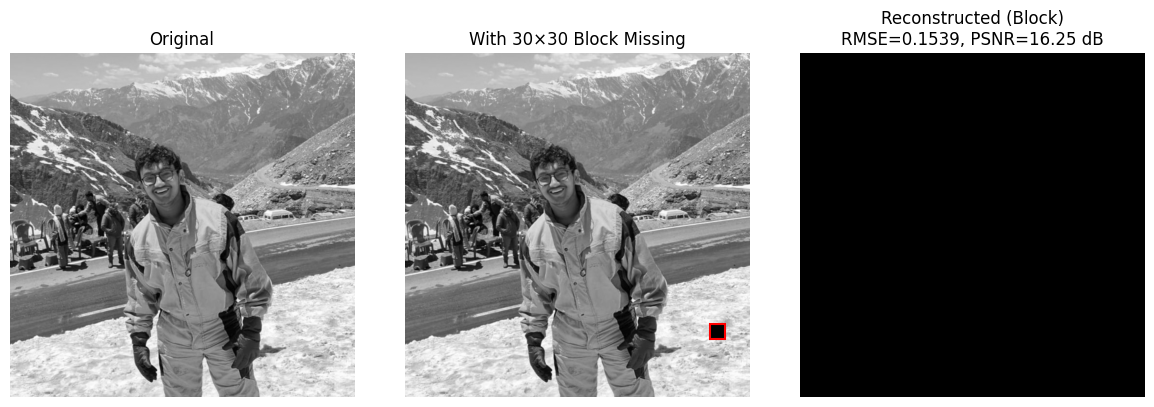

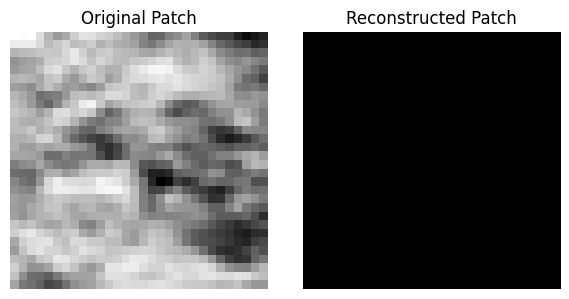

Iter 0, loss = 0.372761
Loss became NaN/Inf, stopping.

[Random Missing] Rank=10
RMSE (missing pixels) = 0.4725
PSNR (missing pixels) = 6.51 dB


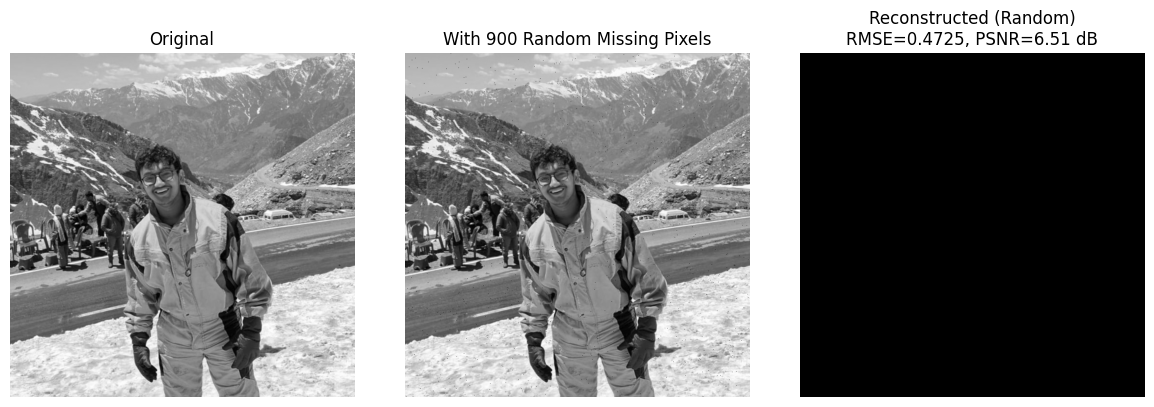

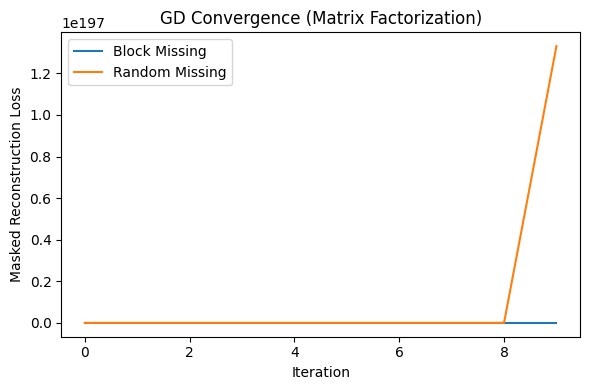

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# 0. Config
# =========================

IMAGE_PATH = "Profile_pic.jpg"
RANK = 30          # higher rank -> better details, but heavier
BLOCK_SIZE = 30
NUM_MISSING = 900


# =========================
# 1. Load & preprocess image
# =========================

img = imread(IMAGE_PATH)

# Convert to grayscale if RGB
if img.ndim == 3:
    img_gray = img.mean(axis=2)
else:
    img_gray = img

# Normalize to [0,1]
img_gray = img_gray.astype(float)
img_min, img_max = img_gray.min(), img_gray.max()
if img_max > img_min:
    img_gray = (img_gray - img_min) / (img_max - img_min)

X_full = img_gray
m, n = X_full.shape
print("Image shape:", X_full.shape)


# =========================
# 2. Mask creation
# =========================

def make_block_mask(shape, block_h=30, block_w=30, top=None, left=None):
    m, n = shape
    M = np.ones((m, n), dtype=float)
    if top is None:
        top = np.random.randint(0, m - block_h + 1)
    if left is None:
        left = np.random.randint(0, n - block_w + 1)
    M[top:top + block_h, left:left + block_w] = 0.0
    return M, (top, left, block_h, block_w)

def make_random_mask(shape, num_missing=900):
    m, n = shape
    M = np.ones((m, n), dtype=float)
    total_pixels = m * n
    num_missing = min(num_missing, total_pixels)
    idx = np.random.choice(total_pixels, size=num_missing, replace=False)
    M.flat[idx] = 0.0
    return M


# =========================
# 3. Matrix factorization via GD (tuned)
# =========================

def matrix_factorization_gd(X, M, rank=50, lr=5e-3, max_iters=10000, tol=1e-6, verbose=True):
    """
    X: ground truth image (m x n), values in [0,1]
    M: mask (m x n), 1 = observed, 0 = missing
    rank: low-rank dimension r
    lr: learning rate
    """
    m, n = X.shape
    r = rank

    # small random init
    U = 0.01 * np.random.randn(m, r)
    V = 0.01 * np.random.randn(n, r)

    losses = []
    obs_count = M.sum()

    for t in range(max_iters):
        X_hat = U @ V.T
        E = (X_hat - X) * M  # error only on known pixels

        # loss as MSE over observed entries (just for monitoring)
        loss = np.sum(E**2) / obs_count
        losses.append(loss)

        if verbose and t % 500 == 0:
            print(f"Iter {t}, loss = {loss:.6f}")

        if not np.isfinite(loss):
            print("Loss became NaN/Inf, stopping.")
            break

        # 🔥 Gradients (no extra 1/obs_count here; lr already small)
        dU = 2.0 * (E @ V)
        dV = 2.0 * (E.T @ U)

        U -= lr * dU
        V -= lr * dV

        # simple convergence on loss change
        if t > 0 and abs(losses[-2] - losses[-1]) < tol:
            if verbose:
                print(f"Converged at iter {t}, loss={loss:.6f}")
            break

    X_rec = U @ V.T
    X_rec = np.clip(X_rec, 0.0, 1.0)
    return X_rec, U, V, np.array(losses)


# =========================
# 4. Metrics
# =========================

def rmse(gt, pred, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]
    else:
        diff = gt - pred
    return np.sqrt(np.mean(diff**2))

def psnr(gt, pred, max_val=1.0, mask=None):
    if mask is not None:
        diff = (gt - pred)[mask == 0]
    else:
        diff = gt - pred
    mse_val = np.mean(diff**2)
    if mse_val == 0:
        return float("inf")
    return 20 * np.log10(max_val / np.sqrt(mse_val))


# =========================
# 5. Case (a): 30×30 block missing
# =========================

np.random.seed(0)
M_block, (top, left, bh, bw) = make_block_mask(X_full.shape, block_h=BLOCK_SIZE, block_w=BLOCK_SIZE)
X_block = X_full * M_block

print("Block region → top={}, left={}, h={}, w={}".format(top, left, bh, bw))

X_rec_block, U_block, V_block, losses_block = matrix_factorization_gd(
    X_full, M_block, rank=RANK, lr=5e-3, max_iters=4000, tol=1e-7, verbose=True
)

rmse_block = rmse(X_full, X_rec_block, mask=M_block)
psnr_block = psnr(X_full, X_rec_block, max_val=1.0, mask=M_block)
print(f"\n[Block Missing] Rank={RANK}")
print(f"RMSE (missing region) = {rmse_block:.4f}")
print(f"PSNR (missing region) = {psnr_block:.2f} dB")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_block, cmap='gray')
axes[1].set_title("With 30×30 Block Missing")
axes[1].add_patch(
    plt.Rectangle((left, top), bw, bh, edgecolor='red', facecolor='none', linewidth=1.5)
)
axes[1].axis('off')

axes[2].imshow(X_rec_block, cmap='gray')
axes[2].set_title(f"Reconstructed (Block)\nRMSE={rmse_block:.4f}, PSNR={psnr_block:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# zoomed patch
patch_orig = X_full[top:top+bh, left:left+bw]
patch_rec = X_rec_block[top:top+bh, left:left+bw]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(patch_orig, cmap='gray')
axes[0].set_title("Original Patch")
axes[0].axis('off')

axes[1].imshow(patch_rec, cmap='gray')
axes[1].set_title("Reconstructed Patch")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# =========================
# 6. Case (b): 900 random pixels missing
# =========================

np.random.seed(1)
M_rand = make_random_mask(X_full.shape, num_missing=NUM_MISSING)
X_rand = X_full * M_rand

X_rec_rand, U_rand, V_rand, losses_rand = matrix_factorization_gd(
    X_full, M_rand, rank=RANK, lr=5e-3, max_iters=4000, tol=1e-7, verbose=True
)

rmse_rand = rmse(X_full, X_rec_rand, mask=M_rand)
psnr_rand = psnr(X_full, X_rec_rand, max_val=1.0, mask=M_rand)
print(f"\n[Random Missing] Rank={RANK}")
print(f"RMSE (missing pixels) = {rmse_rand:.4f}")
print(f"PSNR (missing pixels) = {psnr_rand:.2f} dB")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_full, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_rand, cmap='gray')
axes[1].set_title("With 900 Random Missing Pixels")
axes[1].axis('off')

axes[2].imshow(X_rec_rand, cmap='gray')
axes[2].set_title(f"Reconstructed (Random)\nRMSE={rmse_rand:.4f}, PSNR={psnr_rand:.2f} dB")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 7. Loss curves
# =========================

plt.figure(figsize=(6, 4))
plt.plot(losses_block, label="Block Missing")
plt.plot(losses_rand, label="Random Missing")
plt.xlabel("Iteration")
plt.ylabel("Masked Reconstruction Loss")
plt.title("GD Convergence (Matrix Factorization)")
plt.legend()
plt.tight_layout()
plt.show()


Image shape: (710, 710, 3)

=== Patch case: single_color (top=30, left=40) ===


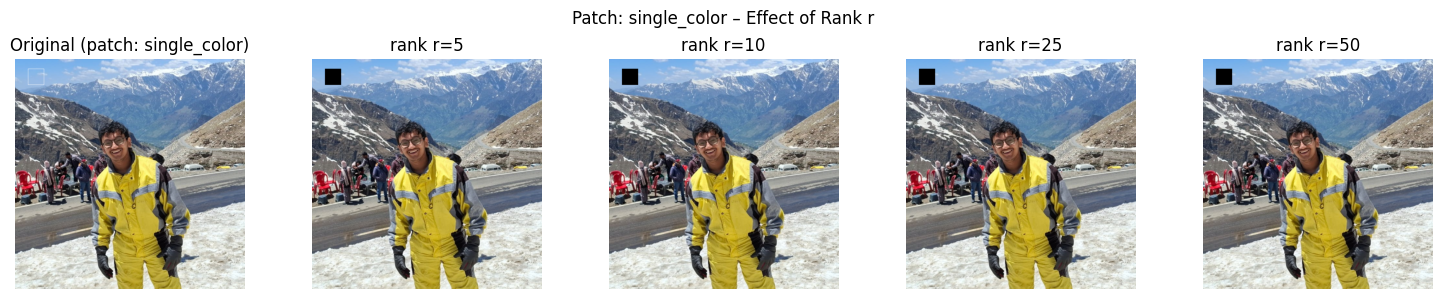


=== Patch case: few_colors (top=120, left=80) ===


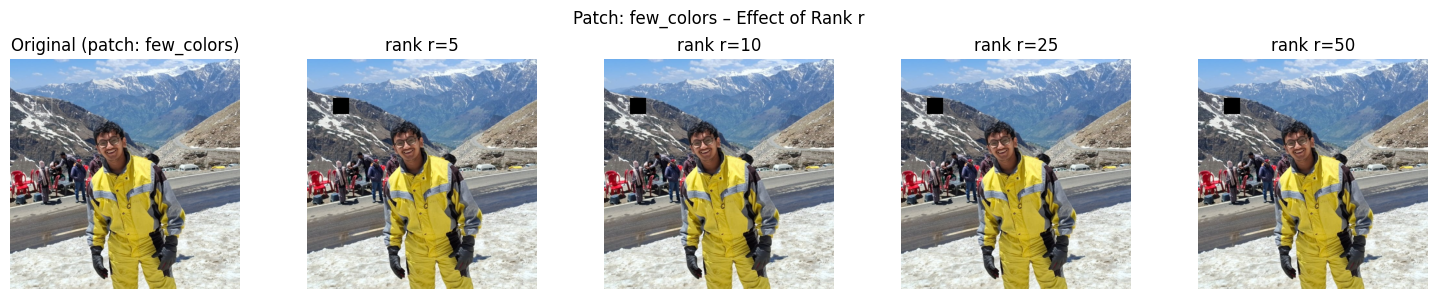


=== Patch case: many_colors (top=200, left=150) ===


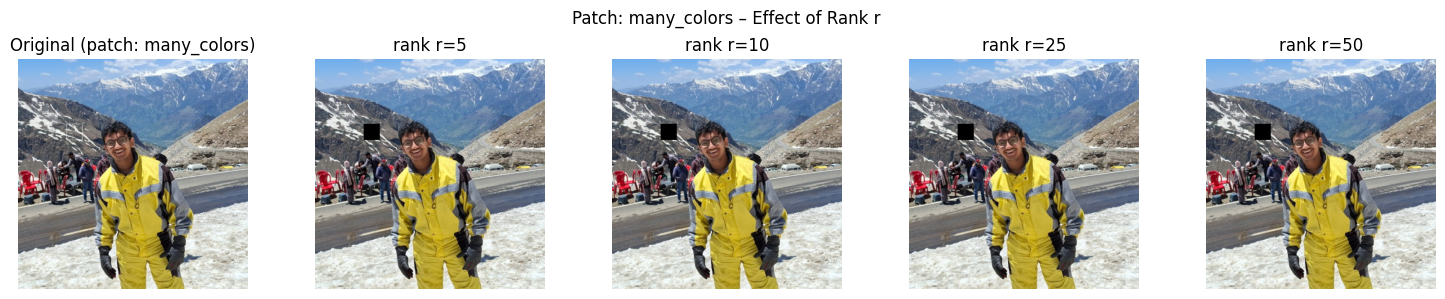

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# 0. Config
# =========================
IMAGE_PATH = "Profile_pic.jpg"   # 🔴 change this
PATCH_SIZE = 50
RANK_VALUES = [5, 10, 25, 50]

# 🔴 You must choose these (top, left) so the 50x50 region matches the case.
# Example values – change based on your image:
patch_specs = [
    {"name": "single_color", "top": 30,  "left": 40},   # mostly uniform area
    {"name": "few_colors",   "top": 120, "left": 80},   # 2–3 colors (e.g., simple object)
    {"name": "many_colors",  "top": 200, "left": 150},  # 5+ colors, textured region
]


# =========================
# 1. Load & preprocess image
# =========================

img = imread(IMAGE_PATH)

# Convert to float [0,1]
img = img.astype(float)
if img.max() > 1.0:
    img = img / 255.0

# Check shape
if img.ndim == 2:
    # grayscale → add channel dimension
    img = img[..., None]

H, W, C = img.shape
print("Image shape:", img.shape)   # (H, W, C)


# =========================
# 2. Low-rank factorization with Gradient Descent
# =========================

def low_rank_gd(X, r, lr=1e-2, max_iters=2000, tol=1e-6, verbose=False):
    """
    X: (m, n) patch matrix
    r: rank
    """
    m, n = X.shape
    U = 0.01 * np.random.randn(m, r)
    V = 0.01 * np.random.randn(n, r)

    prev_loss = None

    for t in range(max_iters):
        X_hat = U @ V.T
        E = X_hat - X
        loss = np.mean(E ** 2)

        if verbose and t % 500 == 0:
            print(f"  iter {t}, loss={loss:.6f}")

        # Convergence check
        if prev_loss is not None and abs(prev_loss - loss) < tol:
            break
        prev_loss = loss

        # Gradients (MSE)
        dU = 2.0 * (E @ V) / (m * n)
        dV = 2.0 * (E.T @ U) / (m * n)

        U -= lr * dU
        V -= lr * dV

    X_hat = U @ V.T
    # Clip back to [0,1]
    X_hat = np.clip(X_hat, 0.0, 1.0)
    return X_hat


# =========================
# 3. Apply to 3 patches and 4 ranks
# =========================

for spec in patch_specs:
    name = spec["name"]
    top = spec["top"]
    left = spec["left"]
    h = PATCH_SIZE
    w = PATCH_SIZE

    print(f"\n=== Patch case: {name} (top={top}, left={left}) ===")

    # Extract original patch
    patch_orig = img[top:top+h, left:left+w, :]   # (50,50,C)

    # Prepare figure:
    # 1 (original) + len(RANK_VALUES) reconstructions
    n_cols = 1 + len(RANK_VALUES)
    plt.figure(figsize=(3 * n_cols, 3))

    # Plot original full image with highlighted patch
    plt.subplot(1, n_cols, 1)
    img_with_box = img.copy()
    # draw thin border (if you want)
    # (simple border drawing: set edge rows/cols to 1)
    img_with_box[top:top+h, left, :] = 1.0
    img_with_box[top:top+h, left+w-1, :] = 1.0
    img_with_box[top, left:left+w, :] = 1.0
    img_with_box[top+h-1, left:left+w, :] = 1.0

    if C == 1:
        plt.imshow(img_with_box[..., 0], cmap='gray')
    else:
        plt.imshow(img_with_box)
    plt.title(f"Original (patch: {name})")
    plt.axis('off')

    # For each rank, reconstruct the patch and paste it back
    for j, r in enumerate(RANK_VALUES):
        img_rec = img.copy()

        # Reconstruct each channel of the patch separately
        for c in range(C):
            X_patch = patch_orig[..., c]        # (50,50)
            X_rec = low_rank_gd(X_patch, r, lr=1e-2, max_iters=2000, tol=1e-6)
            img_rec[top:top+h, left:left+w, c] = X_rec

        plt.subplot(1, n_cols, j + 2)
        if C == 1:
            plt.imshow(img_rec[..., 0], cmap='gray')
        else:
            plt.imshow(img_rec)
        plt.title(f"rank r={r}")
        plt.axis('off')

    plt.suptitle(f"Patch: {name} – Effect of Rank r", fontsize=12)
    plt.tight_layout()
    plt.show()


Image shape: (710, 710, 3)

=== Patch case: single_color (top=50, left=50) ===
  patch single_color min=0.3725, max=0.9608


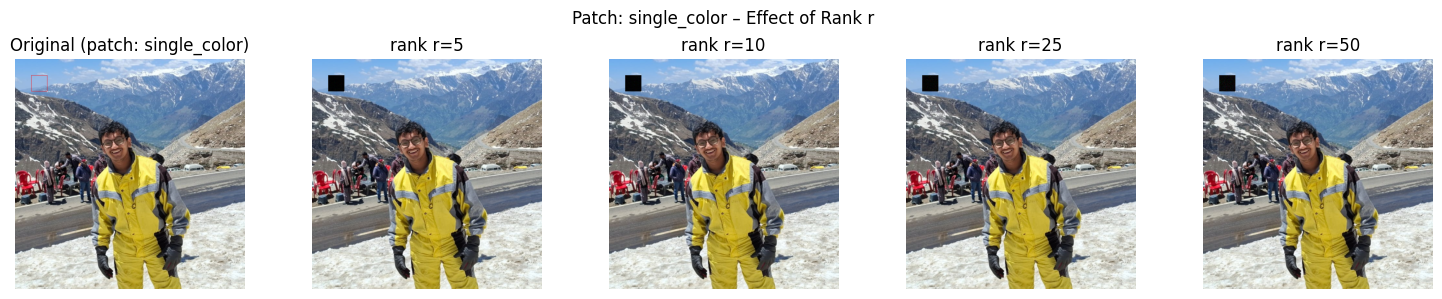


=== Patch case: few_colors (top=150, left=100) ===
  patch few_colors min=0.2353, max=0.9882


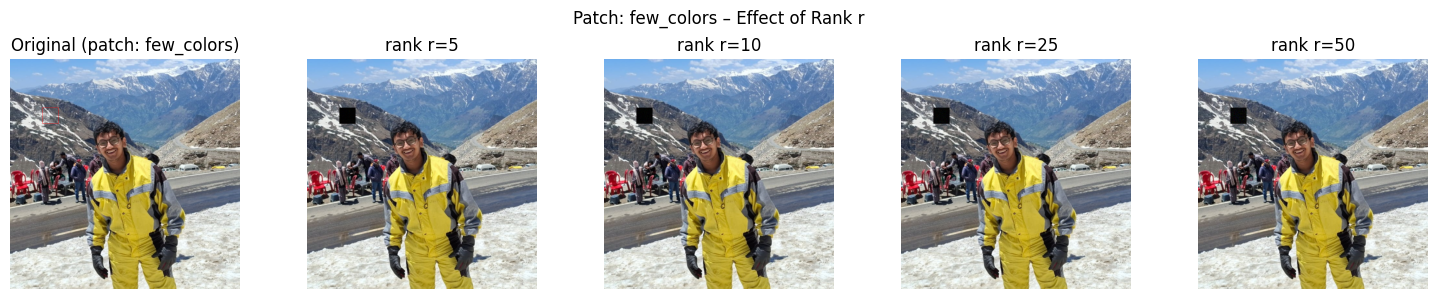


=== Patch case: many_colors (top=250, left=200) ===
  patch many_colors min=0.0863, max=0.9765


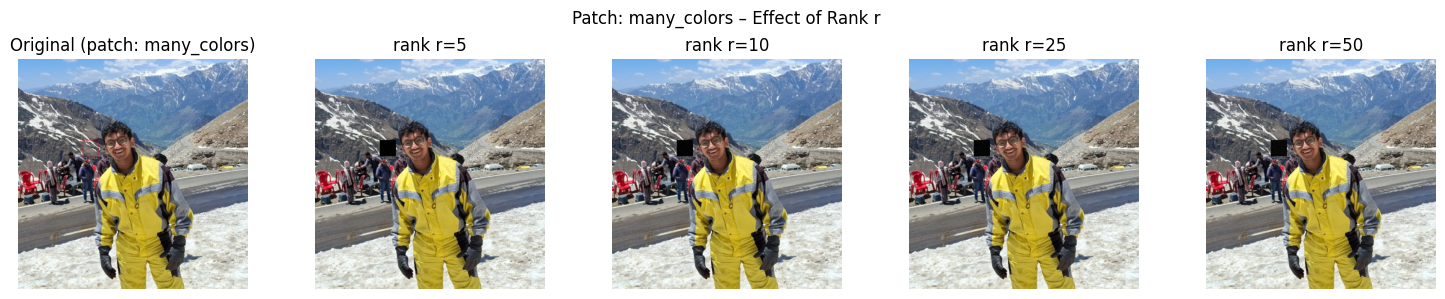

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

# =========================
# 0. Config
# =========================

IMAGE_PATH = "Profile_pic.jpg"   # 🔴 change this to your file

PATCH_SIZE = 50
RANK_VALUES = [5, 10, 25, 50]

# 🔴 Choose 3 patches (top, left) for:
#   1) mostly single color
#   2) 2–3 colors
#   3) 5+ colors / textured
patch_specs = [
    {"name": "single_color", "top": 50,  "left": 50},
    {"name": "few_colors",   "top": 150, "left": 100},
    {"name": "many_colors",  "top": 250, "left": 200},
]


# =========================
# 1. Load & preprocess image
# =========================

img = imread(IMAGE_PATH)

# Convert to float [0,1]
img = img.astype(np.float32)
if img.max() > 1.5:   # likely 0–255
    img = img / 255.0

# Ensure (H, W, C) shape
if img.ndim == 2:     # grayscale
    img = img[..., None]

H, W, C = img.shape
print("Image shape:", img.shape)


# =========================
# 2. Low-rank factorization (stable GD)
# =========================

def low_rank_gd(X, r, lr=5e-3, max_iters=3000, tol=1e-6, verbose=False):
    """
    X: (m, n) patch matrix in [0,1]
    r: rank
    Uses simple gradient descent to minimize ||X - UV^T||_F^2
    """
    m, n = X.shape
    U = 0.1 * np.random.randn(m, r).astype(np.float32)
    V = 0.1 * np.random.randn(n, r).astype(np.float32)

    prev_loss = None

    for t in range(max_iters):
        X_hat = U @ V.T
        E = X_hat - X

        loss = np.mean(E ** 2)

        if verbose and t % 500 == 0:
            print(f"  iter {t}, loss={loss:.6f}")

        if prev_loss is not None and abs(prev_loss - loss) < tol:
            # converged
            break
        prev_loss = loss

        # Gradients (MSE)
        # scale by m,n to keep step sizes reasonable
        dU = 2.0 * (E @ V) / (m * n)
        dV = 2.0 * (E.T @ U) / (m * n)

        U -= lr * dU
        V -= lr * dV

        # safety: clip to avoid explosion
        U = np.clip(U, -5.0, 5.0)
        V = np.clip(V, -5.0, 5.0)

    X_hat = U @ V.T
    X_hat = np.clip(X_hat, 0.0, 1.0)
    return X_hat


# =========================
# 3. Apply to 3 patches and 4 ranks
# =========================

for spec in patch_specs:
    name = spec["name"]
    top = spec["top"]
    left = spec["left"]
    h = PATCH_SIZE
    w = PATCH_SIZE

    # bounds check (so you don't silently get empty patches)
    if top < 0 or left < 0 or top + h > H or left + w > W:
        print(f"⚠️ Patch {name} out of bounds, skipping")
        continue

    print(f"\n=== Patch case: {name} (top={top}, left={left}) ===")

    # Extract original patch
    patch_orig = img[top:top+h, left:left+w, :]   # (50,50,C)
    print(f"  patch {name} min={patch_orig.min():.4f}, max={patch_orig.max():.4f}")

    # If min≈max≈0, the region is just black → you WILL see all black.
    # Choose a different (top,left) in that case.

    # Figure: original + reconstructions
    n_cols = 1 + len(RANK_VALUES)
    plt.figure(figsize=(3 * n_cols, 3))

    # 1) Show original image with a red box marking patch
    plt.subplot(1, n_cols, 1)
    img_with_box = img.copy()

    # draw red border on patch (works for RGB; for grayscale you'll see white)
    img_with_box[top:top+h, left, :] = [1, 0, 0] if C == 3 else 1.0
    img_with_box[top:top+h, left+w-1, :] = [1, 0, 0] if C == 3 else 1.0
    img_with_box[top, left:left+w, :] = [1, 0, 0] if C == 3 else 1.0
    img_with_box[top+h-1, left:left+w, :] = [1, 0, 0] if C == 3 else 1.0

    if C == 1:
        plt.imshow(img_with_box[..., 0], cmap='gray')
    else:
        plt.imshow(img_with_box)
    plt.title(f"Original (patch: {name})")
    plt.axis('off')

    # 2) For each rank, reconstruct patch and paste back
    for j, r in enumerate(RANK_VALUES):
        img_rec = img.copy()

        for c in range(C):
            X_patch = patch_orig[..., c]      # (50,50)
            X_rec = low_rank_gd(X_patch, r, lr=5e-3, max_iters=3000, tol=1e-6)
            img_rec[top:top+h, left:left+w, c] = X_rec

        plt.subplot(1, n_cols, j + 2)
        if C == 1:
            plt.imshow(img_rec[..., 0], cmap='gray')
        else:
            plt.imshow(img_rec)
        plt.title(f"rank r={r}")
        plt.axis('off')

    plt.suptitle(f"Patch: {name} – Effect of Rank r", fontsize=12)
    plt.tight_layout()
    plt.show()
